In [9]:
# Libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import openpyxl
import datetime as dt

In [10]:
import VPP_model_household as house
import VPP_model_NEM as nem
import VPP_origin as origin

In [11]:
# Data stuff
# Import one of the households for individual data from excel
print("Importing individual data...")
household_num = 137
fname = "dataOut/origin_vpp_{}.xlsx".format(household_num)
df_ind_sc = pd.read_excel(fname)
fname = "dataOut/self_consume_{}.xlsx".format(household_num)
df_ind_vpp = pd.read_excel(fname)
print("Individual data imported.")

Importing individual data...
Individual data imported.


In [12]:
print("Importing aggregate data...")
# Import the time series aggregate data from excel
df_agg_time = pd.read_excel("annual_total_by_time.xlsx")
t = pd.to_datetime(df_agg_time.iloc[:,0])
df_agg_time = df_agg_time.iloc[:,1:]
df_agg_time.index = t

# Import the totals by household for self consumption
df_agg_tot_sc = pd.read_excel("self_consumption_total_by_household.xlsx")

# Import the totals by household for origin VPP
df_agg_tot_vpp = pd.read_excel("vpp_total_by_household.xlsx")
print("Aggregate data imported.")

Importing aggregate data...
Aggregate data imported.


107 days, 0:00:00


Text(20, 4, 'BESS SoC')

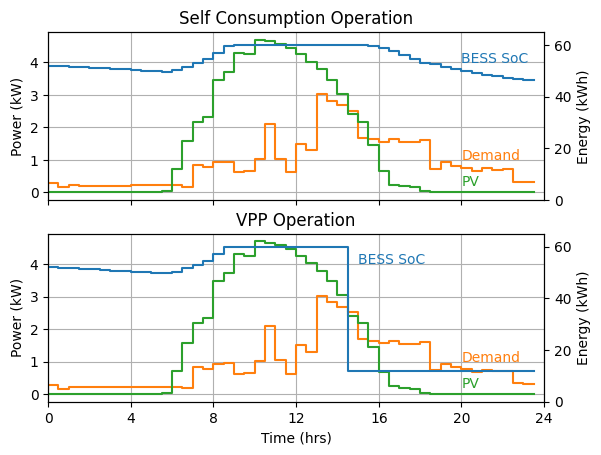

In [97]:
# Individual data plots

# Get times for grid event
# Grid event at 16/10/2012  3:30:00 PM
t_start = dt.datetime(2012, 7, 1, 0, 30, 0)
t_event = dt.datetime(2012, 10, 16, 0, 30, 0)
diff = t_event - t_start
print(diff)
i_start = int(2*divmod(diff.total_seconds(), 3600)[0])
i_end = int(i_start+48)
t_hrs= np.arange(0, 24, 0.5)

plt.figure()
# Plot self consumption
ax = plt.subplot(2,1,2)
ax.grid()
ax.set_title("VPP Operation")
dat_24hr_sc = df_ind_sc.iloc[i_start:i_end,:]

# Data: Self Consumption
# Battery SoC
soc = dat_24hr_sc['SoC (kWh)']
# Load
load = dat_24hr_sc['load']
# PV Generation
pv = dat_24hr_sc['PV']


# Plot
ax.step(t_hrs, load*2, label = "Demand", color="tab:orange")
ax.step(t_hrs, pv*2, label = "PV Generation", color = "tab:green")

# Tidy up the plot
ax.set_xlabel("Time (hrs)")
ax.set_ylabel("Power (kW)")

ax_soc = ax.twinx()
color = "tab:blue"
ax_soc.set_ylabel("Energy (kWh)")
ax_soc.step(t_hrs, soc*2, label = "SoC")
ax_soc.set_ylim([0, 65])

ax.set_xlim([0, 24])
ax.set_xticks(np.arange(0,25,4))
ax.annotate("PV", (20, 0.2), color="tab:green")
ax.annotate("Demand", (20, 1), color="tab:orange")
ax.annotate("BESS SoC", (15, 4), color="tab:blue")

# Plot VPP
ax = plt.subplot(2,1,1)
dat_24hr_vpp = df_ind_vpp.iloc[i_start:i_end,:]

# Data: subplot 2
# Battery SoC
soc = dat_24hr_vpp['SoC (kWh)']
# Load
load = dat_24hr_vpp['load']
# PV Generation
pv = dat_24hr_vpp['PV']

# Plot
ax.step(t_hrs, load*2, label = "Demand", color="tab:orange")
ax.step(t_hrs, pv*2, label = "PV Generation", color="tab:green")
ax.grid()
ax.set_ylabel("Power (kW)")
ax.set_title("Self Consumption Operation")

ax_soc = ax.twinx()
color = "tab:blue"
ax_soc.set_ylabel("Energy (kWh)")
ax_soc.step(t_hrs, soc*2, label = "SoC")
ax_soc.set_ylim([0, 65])
ax.set_xticks(range(0,24,4), labels = [])
ax.set_xlim([0, 24])
ax.annotate("PV", (20, 0.2), color="tab:green")
ax.annotate("Demand", (20, 1), color="tab:orange")
ax.annotate("BESS SoC", (20, 4), color="tab:blue")

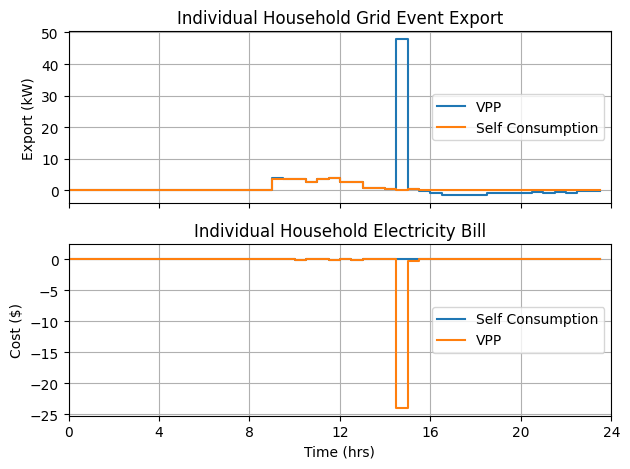

In [82]:
# Data subplot 2
plt.figure()

# Export/Import: PV and battery
ax = plt.subplot(2,1,1)
ax.grid()
# Plot for self consumption
# Export
exp = dat_24hr_sc['Export (kWh)'] - dat_24hr_sc['Import (kWh)']
ax.step(t_hrs, exp*2, label = "VPP")
exp = dat_24hr_vpp['Export (kWh)'] - dat_24hr_vpp['Import (kWh)']
ax.step(t_hrs, exp*2, label = "Self Consumption")
ax.set_ylabel("Export (kW)")
ax.legend(loc = "center right")
ax.set_title("Individual Household Grid Event Export")
ax.set_xlim([0, 24])
ax.set_xticks(np.arange(0,25,4), labels=[])
# Plot
ax = plt.subplot(2,1,2)
ax.grid()

#spot = dat_24hr_sc['Spot Price ($/kWh)']
#ax.step(t_hrs, spot, label = "Spot Price")
bill = -dat_24hr_vpp['Total Profit ($)']
ax.step(t_hrs, bill, label = "Self Consumption")
bill = -dat_24hr_sc['Total Profit ($)']
ax.step(t_hrs, bill, label = "VPP")
ax.set_ylabel("Cost ($)")
ax.set_title("Individual Household Electricity Bill")
ax.legend(loc = "center right")

ax.set_xlabel("Time (hrs)")
ax.set_xlim([0, 24])
ax.set_xticks(np.arange(0,25,4))
plt.tight_layout(h_pad=1)
# Bill cost
# Spot price

# During grid event 
# Same plots as above

# Plot battery SoC over time

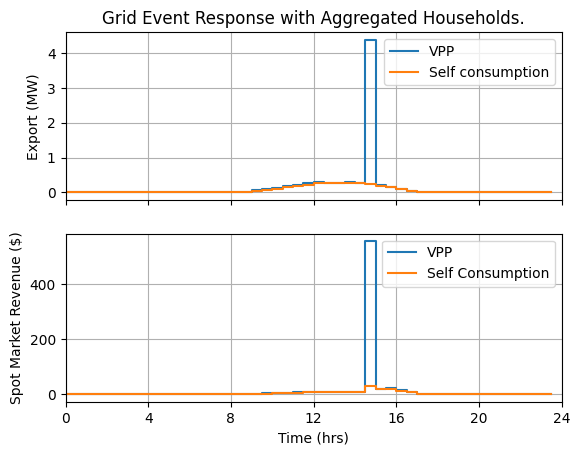

In [84]:
# Aggregate data plots - Totals by time
#print(df_agg_time)

dat_agg_24hr = df_agg_time.iloc[i_start:i_end,:]

# Do plots for above but show aggregate response during grid event

# Show annual response and price spikes with grid event threshold

spot_price = dat_24hr_sc['Spot Price ($/kWh)']

plt.figure()

ax = plt.subplot(2,1,1)
ax.set_ylabel("Export (MW)")
ax.set_title("Grid Event Response with Aggregated Households.")
ax.grid()

exp_vpp = dat_agg_24hr['VPP Export (kWh)']
ax.step(t_hrs, 2*exp_vpp/1000, label = "VPP")
exp_sc = dat_agg_24hr['Self Consumption Export (kWh)']
ax.step(t_hrs, 2*exp_sc/1000, label = "Self consumption")
ax.legend()
ax.set_xlim([0, 24])
ax.set_xticks(np.arange(0,25,4), labels=[])

# Now do pricing
ax = plt.subplot(2,1,2)
ax.grid()

spot_profit_sc = np.zeros(len(spot_price))
spot_profit_vpp = np.zeros(len(spot_price))
for i in range(0, len(spot_price)):
    spot_profit_sc[i] = spot_price.iloc[i]*exp_sc.iloc[i]
    spot_profit_vpp[i] = spot_price.iloc[i]*exp_vpp.iloc[i]

ax.step(t_hrs, spot_profit_vpp, label = "VPP")
ax.step(t_hrs, spot_profit_sc, label = "Self Consumption")

ax.legend()
ax.set_ylabel("Spot Market Revenue ($)")
ax.set_xlabel("Time (hrs)")
ax.set_xlim([0, 24])
ax.set_xticks(np.arange(0,25,4))

Text(0.5, 1.0, 'Spot Price During Grid Event')

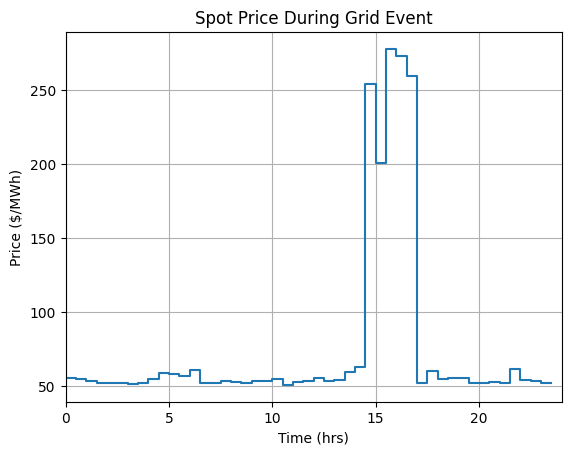

In [44]:
plt.figure()
ax = plt.subplot(1,1,1)
ax.grid()
ax.set_xlim([0, 24])
ax.step(t_hrs, spot_price*1000, label = "Spot Price ($/MWh)")
ax.set_xlabel("Time (hrs)")
ax.set_ylabel("Price ($/MWh)")
ax.set_title("Spot Price During Grid Event")

[    0.  1460.  2920.  4380.  5840.  7300.  8760. 10220. 11680. 13140.
 14600. 16060.]


Text(0.5, 0, 'Time (hrs)')

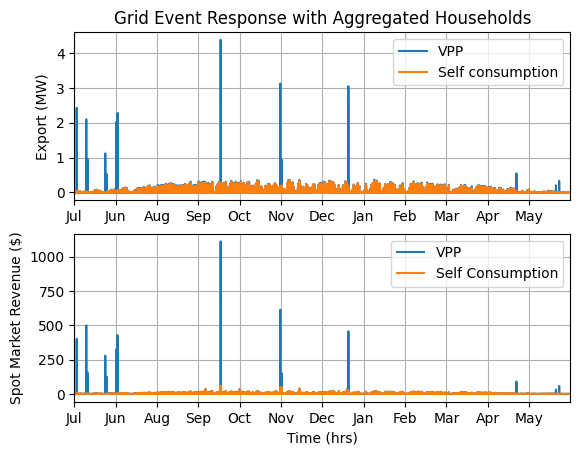

In [16]:
# Aggregate data plots - Totals by time
#print(df_agg_time)

# Do plots for above but show aggregate response during grid event

# Show annual response and price spikes with grid event threshold

spot_price = df_ind_sc['Spot Price ($/kWh)']

t = df_agg_time.index
offset = len(t)/12
x_tick_index = np.arange(0, len(t), offset)
print(x_tick_index)
x_tick_list = []
for i in range(0, len(x_tick_index)):
    x_tick_list.append(t[int(x_tick_index[i])])


plt.figure()

ax = plt.subplot(2,1,1)
ax.set_xlim(t[0], t[-1])
ax.set_title("Grid Event Response with Aggregated Households")
ax.set_xticks(
                x_tick_list,
    labels = ["Jul", "Jun", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May"]
)

exp_vpp = 2*df_agg_time['VPP Export (kWh)']
ax.step(t, exp_vpp/1000, label = "VPP")
exp_sc = 2*df_agg_time['Self Consumption Export (kWh)']
ax.step(t, exp_sc/1000, label = "Self consumption")

# Tidy up the plot
ax.set_ylabel("Export (MW)")
ax.legend()
ax.grid()

# Now do pricing
ax = plt.subplot(2,1,2)
ax.grid()
ax.set_xlim(t[0], t[-1])
ax.set_xticks(
                x_tick_list,
    labels = ["Jul", "Jun", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May"]
)

spot_profit_sc = np.zeros(len(spot_price))
spot_profit_vpp = np.zeros(len(spot_price))
for i in range(0, len(spot_price)):
    spot_profit_sc[i] = spot_price.iloc[i]*exp_sc.iloc[i]
    spot_profit_vpp[i] = spot_price.iloc[i]*exp_vpp.iloc[i]

ax.step(t, spot_profit_vpp, label = "VPP")
ax.step(t, spot_profit_sc, label = "Self Consumption")

ax.legend()
ax.set_ylabel("Spot Market Revenue ($)")
ax.set_xlabel("Time (hrs)")


[    0.  1460.  2920.  4380.  5840.  7300.  8760. 10220. 11680. 13140.
 14600. 16060.]


<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ddani\AppData\Local\Temp\ipykernel_27920\3062855493.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax.annotate("Grid event threshold = $\mu$ + {}$\sigma$".format(threshold_stdDev), (x_tick_list[6], 170), color = "tab:green")


Text(0, 0.5, 'Price ($/MWh)')

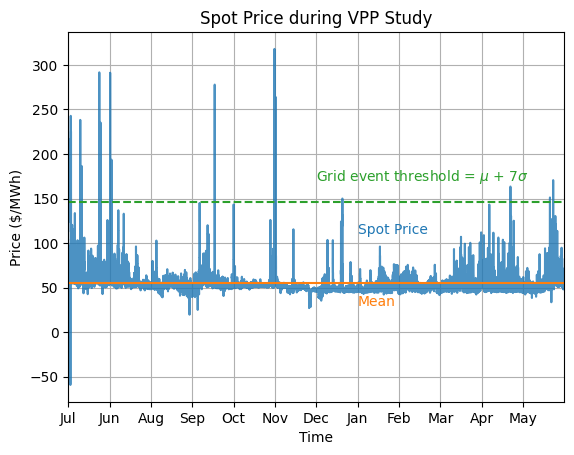

In [17]:
plt.figure()
ax = plt.subplot(1,1,1)
ax.set_xlim([t[0], t[-1]])
offset = len(t)/12
x_tick_index = np.arange(0, len(t), offset)
print(x_tick_index)
x_tick_list = []
ax.set_xticks([])
ax.grid()
for i in range(0, len(x_tick_index)):
    x_tick_list.append(t[int(x_tick_index[i])])
ax.set_xticks(
                x_tick_list,
    labels = ["Jul", "Jun", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May"]
)
#for i in range(0, len(x_tick_index)):
 #   x_tick_arr[i] = t[x_tick_index[i]]
    
threshold_stdDev = 7
spot_mean = spot_price.mean()
spot_stdDev = spot_price.std()

ax.step(t, spot_price*1000, label = "Spot Price ($/MWh)", alpha=0.8)
ax.hlines(spot_mean*1000, t[0], t[-1], label = "Mean", color = "tab:orange")
ax.hlines(
            (spot_mean + threshold_stdDev*spot_stdDev)*1000,
            t[0],
            t[-1],
            label = "Grid event threshold",
            color = "tab:green",
            linestyles = 'dashed'
)
ax.annotate("Grid event threshold = $\mu$ + {}$\sigma$".format(threshold_stdDev), (x_tick_list[6], 170), color = "tab:green")
ax.annotate("Spot Price", (x_tick_list[7], 110), color = "tab:blue")
ax.annotate("Mean", (x_tick_list[7], 30), color = "tab:orange")
ax.set_title("Spot Price during VPP Study")
ax.set_xlabel("Time")
ax.set_ylabel("Price ($/MWh)")

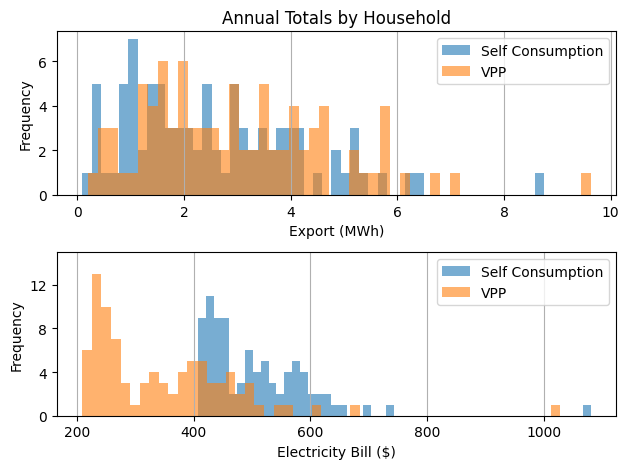

In [38]:
# Aggregate data plots - Totals by household
#print(df_agg_tot_sc)
#print(df_agg_tot_vpp)

# Histograms
plt.figure()
ax = plt.subplot(2,1,1)
ax.set_title("Annual Totals by Household")
ax.set_ylabel("Frequency")
ax.set_xlabel("Export (MWh)")
ax.grid(axis = 'x')

export_sc = df_agg_tot_sc['Export (kWh)']
profit_sc = df_agg_tot_sc['Profit (kWh)']

export_vpp = df_agg_tot_vpp['Export (kWh)']
profit_vpp = df_agg_tot_vpp['Profit (kWh)']

ax.hist(export_sc/1000, bins =50, label = "Self Consumption", alpha = 0.6)
ax.hist(export_vpp/1000, bins = 50, label = "VPP", alpha = 0.6)
ax.legend()

#ax.vlines(export_vpp.mean()/1000, 0, 15, color = "tab:orange", linestyles = 'dashed')
#ax.vlines(export_sc.mean()/1000, 0, 15, color = "tab:blue", linestyles = 'dashed')

ax = plt.subplot(2,1,2)
ax.set_ylabel("Frequency")
ax.set_xlabel("Electricity Bill ($)")
ax.set_ylim([0, 15])
ax.hist(-profit_sc, bins =50, label = "Self Consumption", alpha = 0.6)
ax.hist(-profit_vpp, bins = 50, label = "VPP", alpha = 0.6)
ax.legend()
ax.grid(axis = 'x')
ax.set_yticks(range(0, 16, 4))

plt.tight_layout(h_pad=1)
#ax.vlines(-profit_vpp.mean(), 0, 15, color = "tab:orange", linestyles = 'dashed')
#ax.vlines(-profit_sc.mean(), 0, 15, color = "tab:blue", linestyles = 'dashed')
